In [10]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from collections import Counter
import random
import matplotlib.pyplot as plt



# Load dataset

In [11]:
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names



# Class indices


In [12]:
class_0 = np.where(y == 0)[0]
class_1 = np.where(y == 1)[0]
class_2 = np.where(y == 2)[0]

bags = 5
bag_predictions = []


========== BAG 1 ==========
Tree 1 → Features: ['petal length (cm)', 'sepal length (cm)']


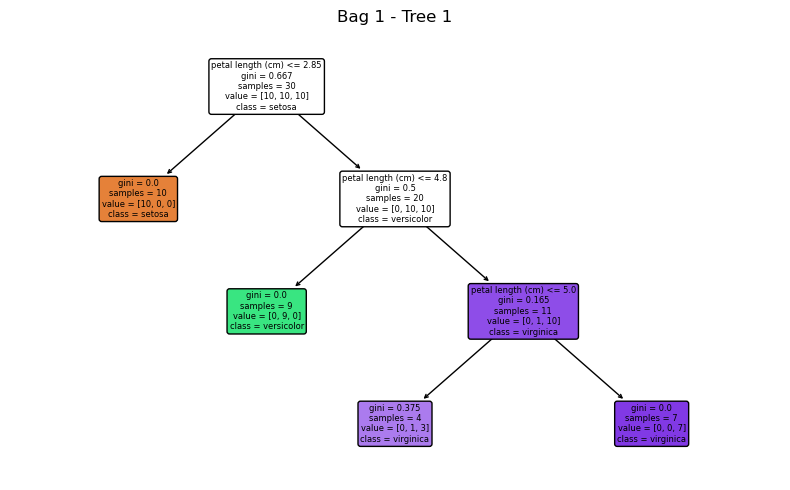

Tree 2 → Features: ['sepal width (cm)', 'petal width (cm)']


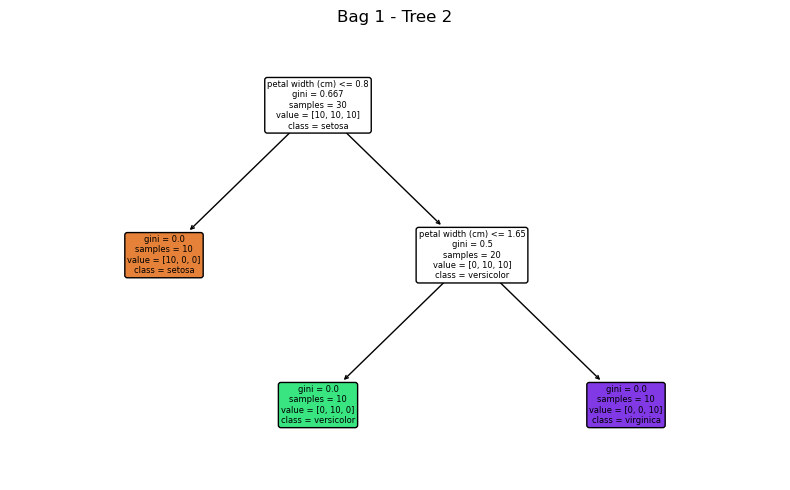

Tree 3 → Features: ['petal length (cm)', 'sepal width (cm)']


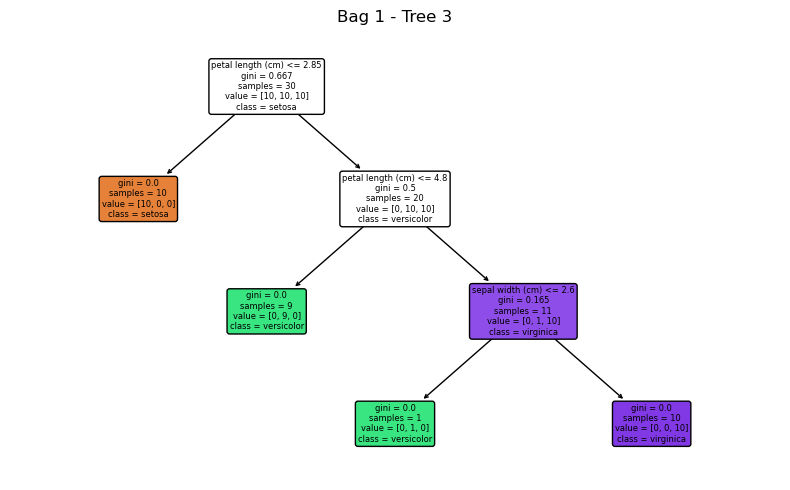

✅ Bag 1 Accuracy: 94.67%

========== BAG 2 ==========
Tree 1 → Features: ['petal width (cm)', 'sepal length (cm)']


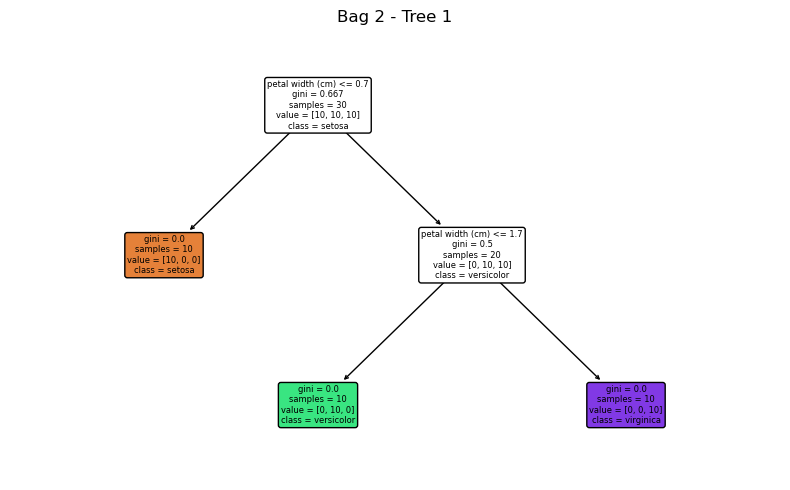

Tree 2 → Features: ['petal width (cm)', 'sepal width (cm)']


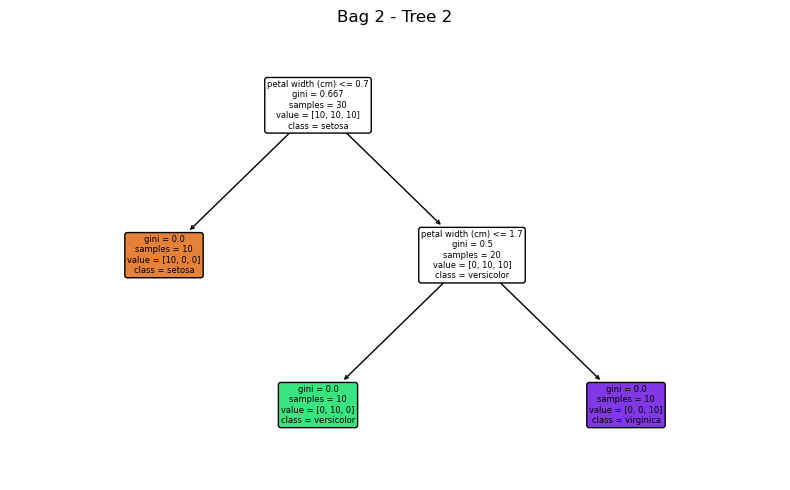

Tree 3 → Features: ['sepal length (cm)', 'sepal width (cm)']


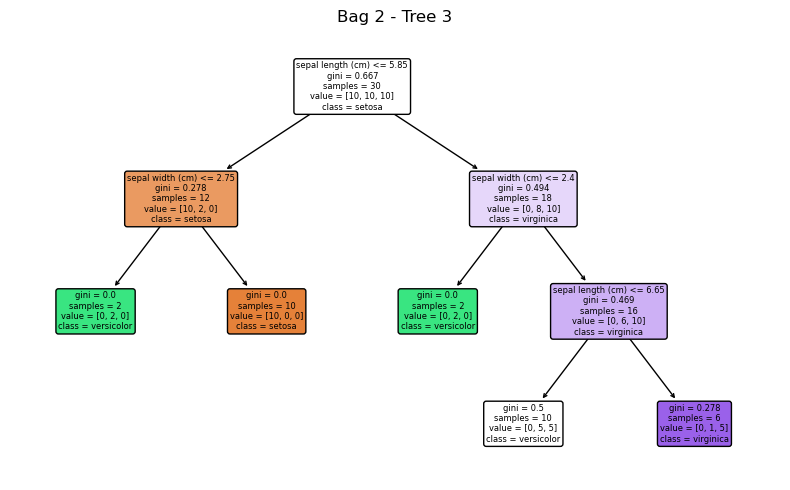

✅ Bag 2 Accuracy: 96.00%

========== BAG 3 ==========
Tree 1 → Features: ['sepal length (cm)', 'petal width (cm)']


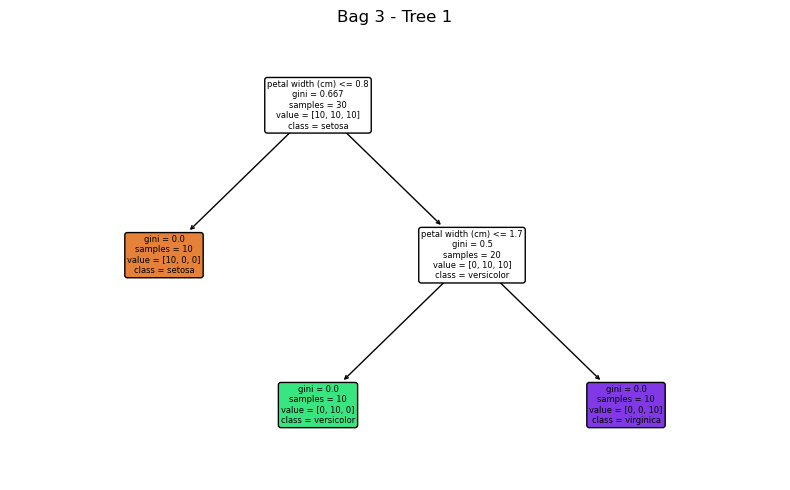

Tree 2 → Features: ['sepal width (cm)', 'petal width (cm)']


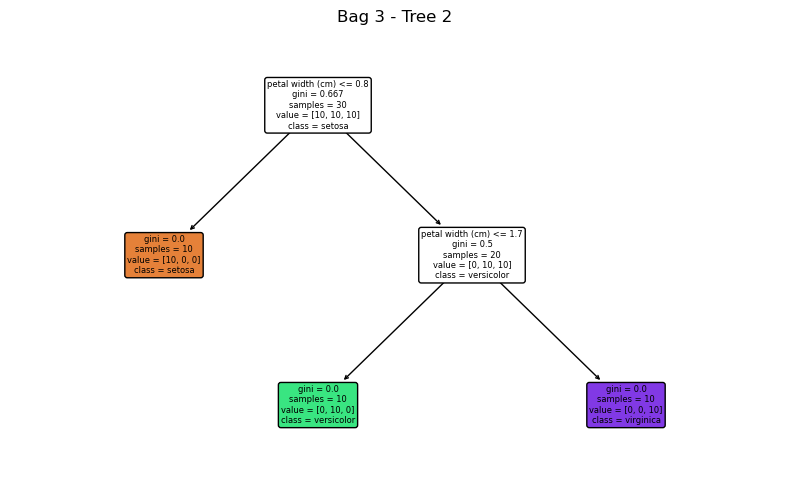

Tree 3 → Features: ['petal width (cm)', 'sepal width (cm)']


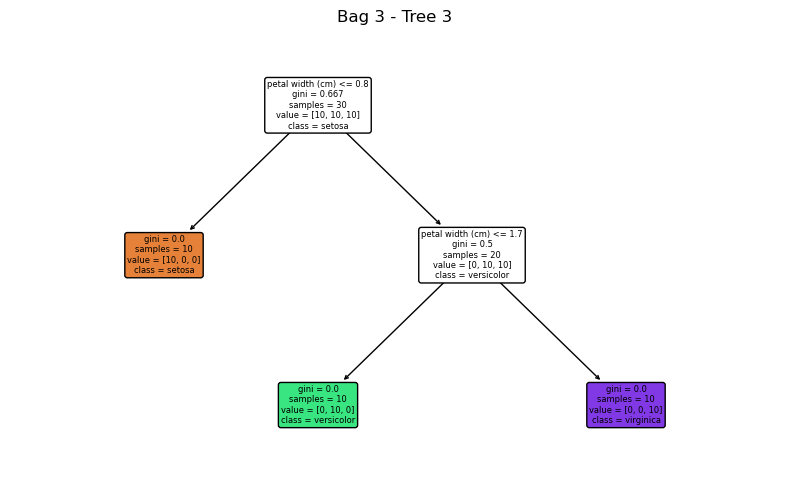

✅ Bag 3 Accuracy: 96.00%

========== BAG 4 ==========
Tree 1 → Features: ['sepal width (cm)', 'sepal length (cm)']


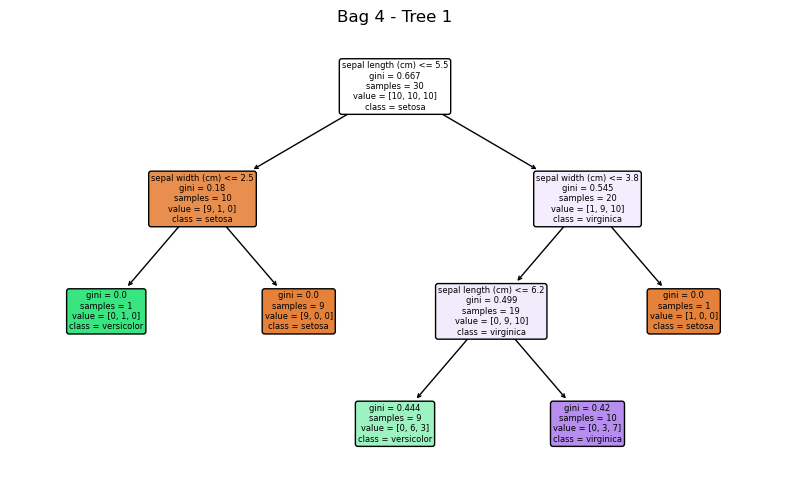

Tree 2 → Features: ['petal width (cm)', 'sepal length (cm)']


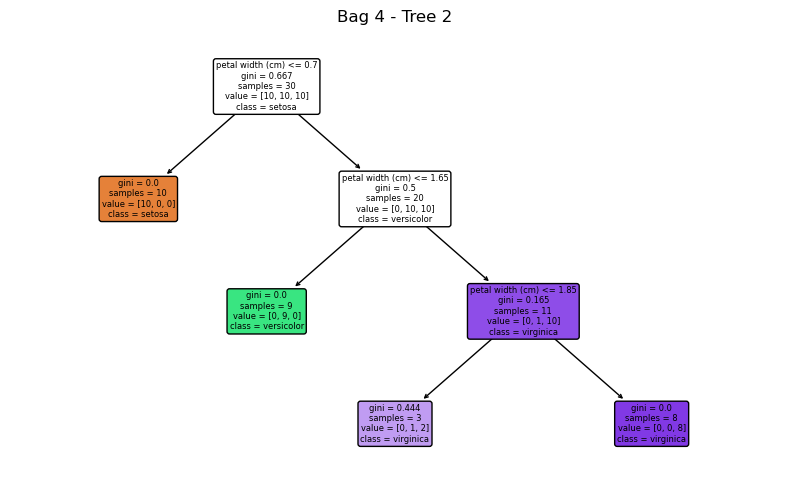

Tree 3 → Features: ['petal width (cm)', 'sepal length (cm)']


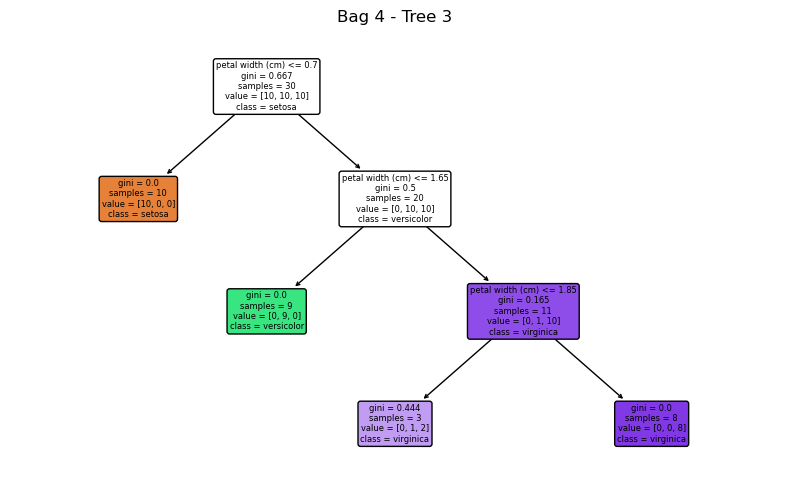

✅ Bag 4 Accuracy: 96.00%

========== BAG 5 ==========
Tree 1 → Features: ['sepal width (cm)', 'sepal length (cm)']


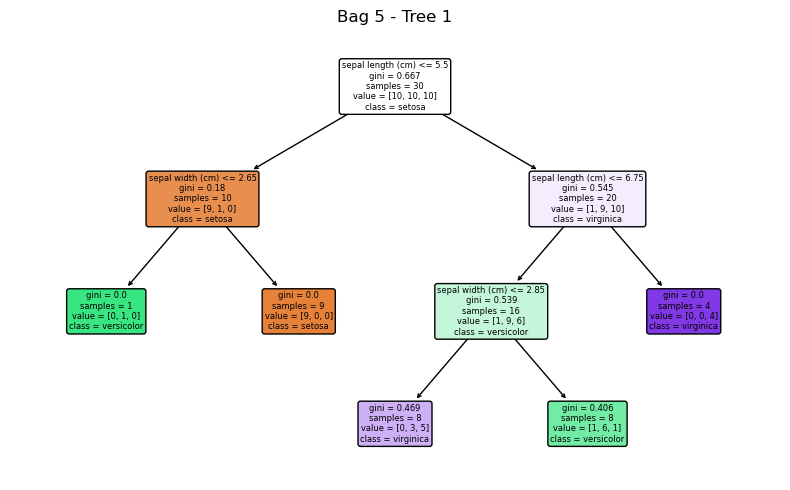

Tree 2 → Features: ['sepal length (cm)', 'sepal width (cm)']


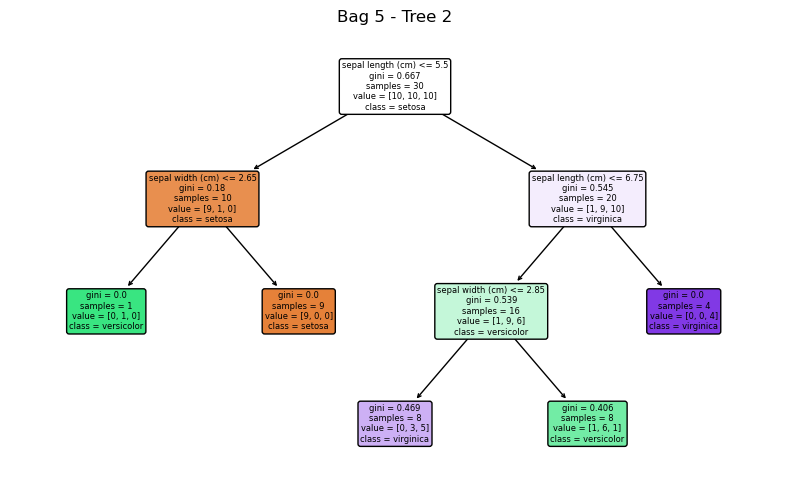

Tree 3 → Features: ['petal width (cm)', 'sepal length (cm)']


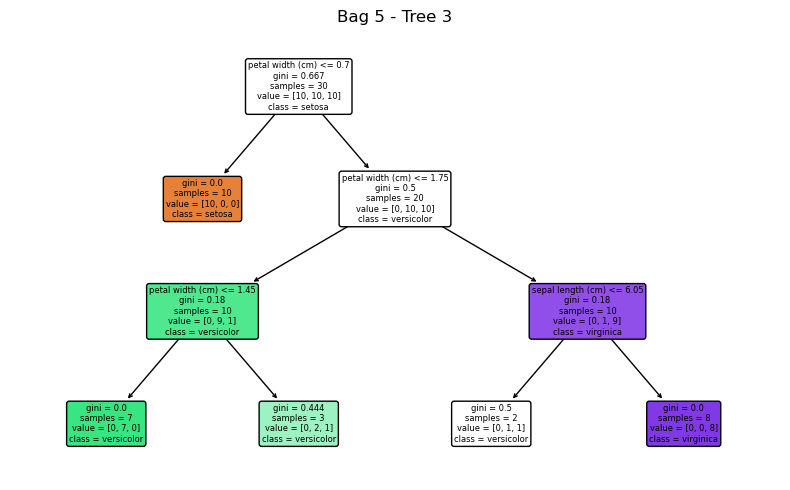

✅ Bag 5 Accuracy: 71.33%


In [13]:
for b in range(bags):
    indices = []

    # 10 samples per class
    indices.extend(np.random.choice(class_0, 10, replace=False))
    indices.extend(np.random.choice(class_1, 10, replace=False))
    indices.extend(np.random.choice(class_2, 10, replace=False))

    indices = np.array(indices)
    trees = []

    print(f"\n========== BAG {b+1} ==========")

    # 🔹 3 Decision Trees per bag
    for t in range(3):
        features = random.sample(range(4), 2)

        X_subset = X[indices][:, features]
        y_subset = y[indices]

        model = DecisionTreeClassifier(max_depth=3)
        model.fit(X_subset, y_subset)

        trees.append((model, features))

        print(f"Tree {t+1} → Features: {[feature_names[f] for f in features]}")

        # 🔹 Neat plot
        plt.figure(figsize=(8, 5))
        plot_tree(model,
                  feature_names=[feature_names[f] for f in features],
                  class_names=class_names,
                  filled=True,
                  rounded=True,
                  fontsize=6)
        plt.title(f"Bag {b+1} - Tree {t+1}")
        plt.tight_layout()
        plt.show()

    # 🔹 Prediction for this bag
    bag_pred = []

    for i in range(len(X)):
        votes = []

        for model, features in trees:
            pred = model.predict(X[i][features].reshape(1, -1))[0]
            votes.append(pred)

        final_vote = Counter(votes).most_common(1)[0][0]
        bag_pred.append(final_vote)

    bag_predictions.append(bag_pred)

    # 🔹 Accuracy per bag
    correct = sum(1 for i in range(len(y)) if y[i] == bag_pred[i])
    acc = correct / len(y)

    print(f"✅ Bag {b+1} Accuracy: {acc*100:.2f}%")



In [14]:
# 🔹 Final ensemble prediction
final_predictions = []

for i in range(len(X)):
    votes = [bag_predictions[b][i] for b in range(bags)]
    final_vote = Counter(votes).most_common(1)[0][0]
    final_predictions.append(final_vote)
    
print("Final Class:", iris.target_names[final_vote])
# 🔹 Final accuracy
correct = sum(1 for i in range(len(y)) if y[i] == final_predictions[i])
final_acc = correct / len(y)

print(f"\n Final Model Accuracy: {final_acc*100:.2f}%")

Final Class: virginica

 Final Model Accuracy: 96.00%



========== BAG 1 ==========
SVM 1 trained (PCA space)


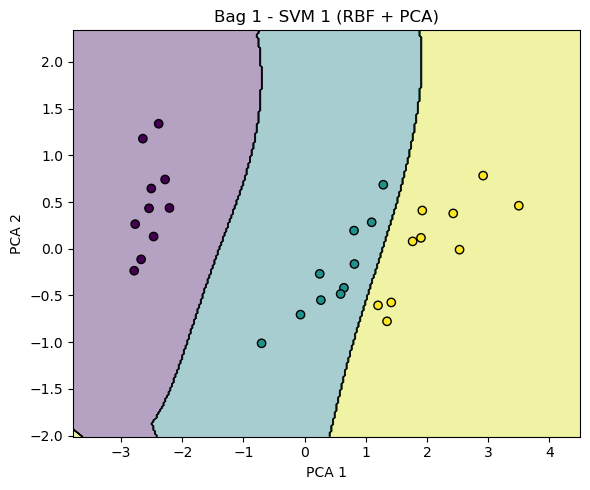

SVM 2 trained (PCA space)


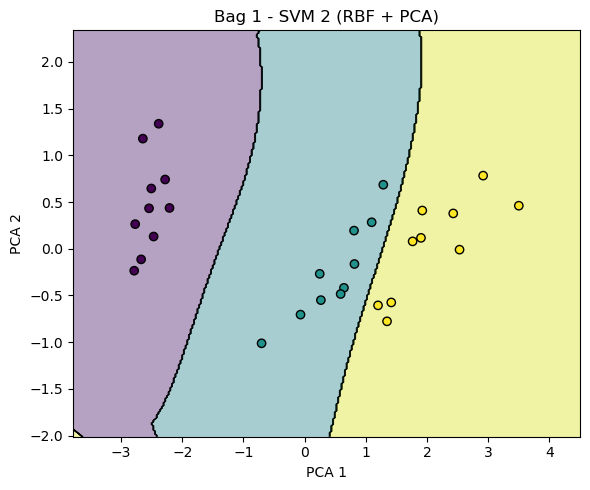

SVM 3 trained (PCA space)


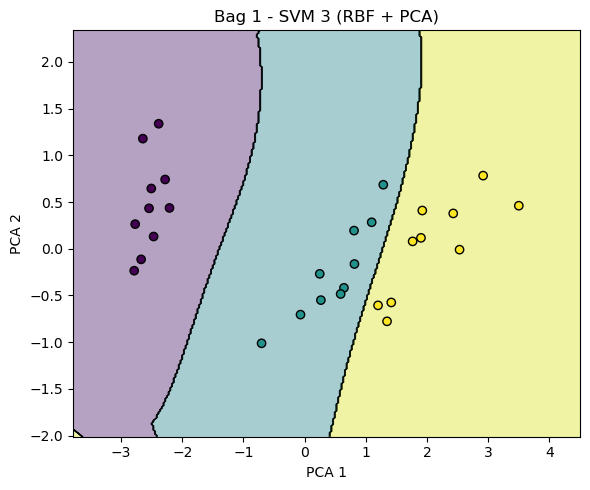

✅ Bag 1 Accuracy: 96.67%

========== BAG 2 ==========
SVM 1 trained (PCA space)


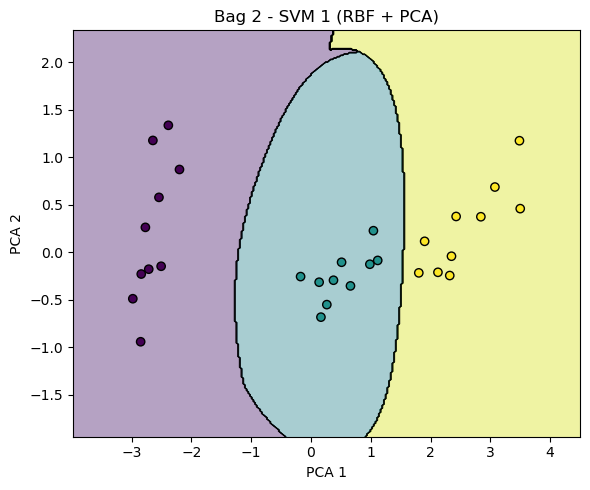

SVM 2 trained (PCA space)


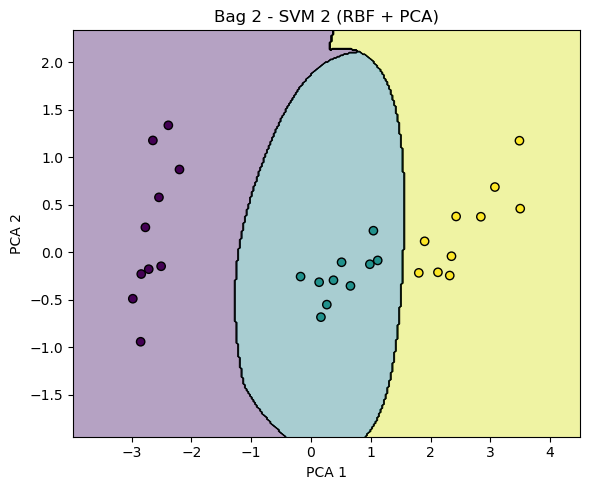

SVM 3 trained (PCA space)


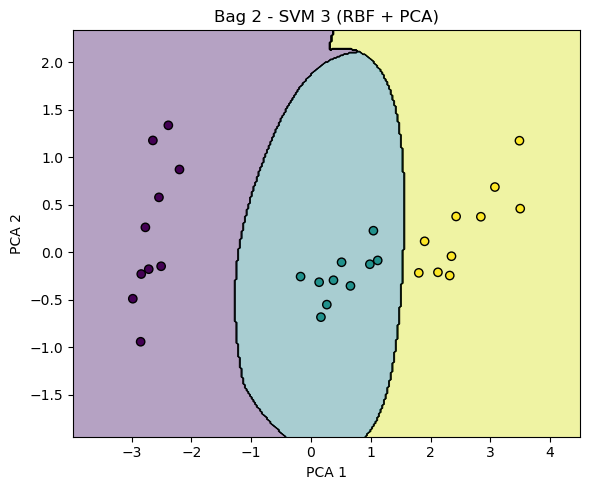

✅ Bag 2 Accuracy: 92.00%

========== BAG 3 ==========
SVM 1 trained (PCA space)


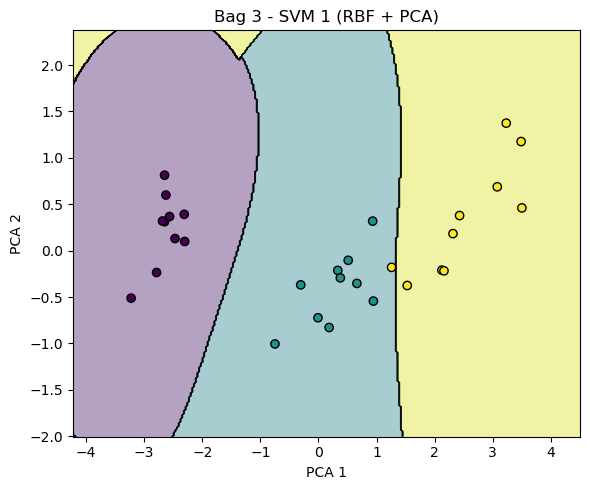

SVM 2 trained (PCA space)


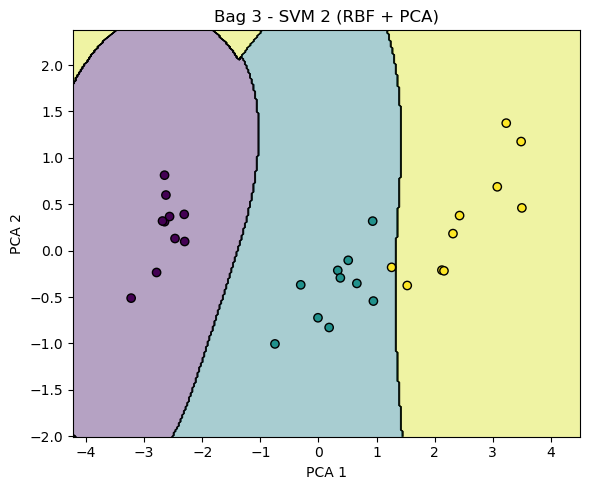

SVM 3 trained (PCA space)


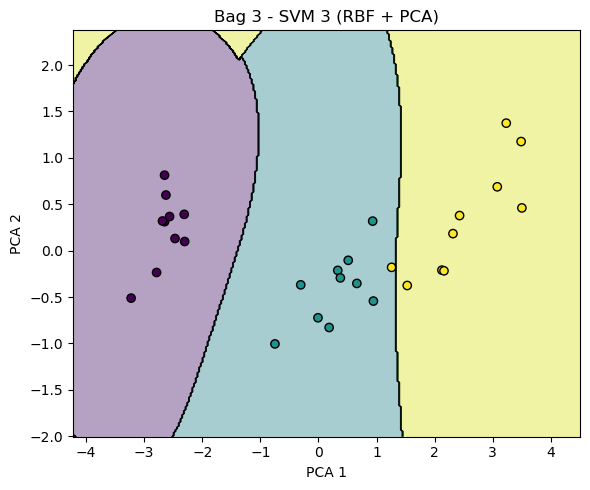

✅ Bag 3 Accuracy: 94.00%

========== BAG 4 ==========
SVM 1 trained (PCA space)


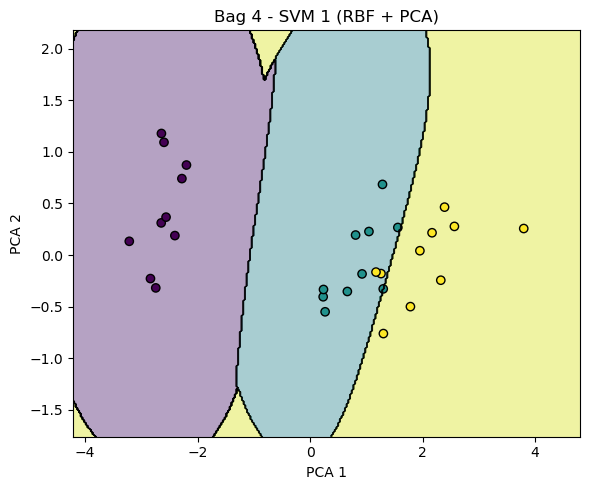

SVM 2 trained (PCA space)


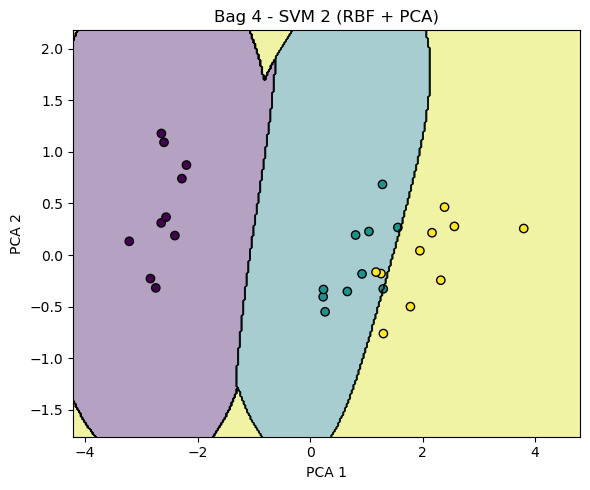

SVM 3 trained (PCA space)


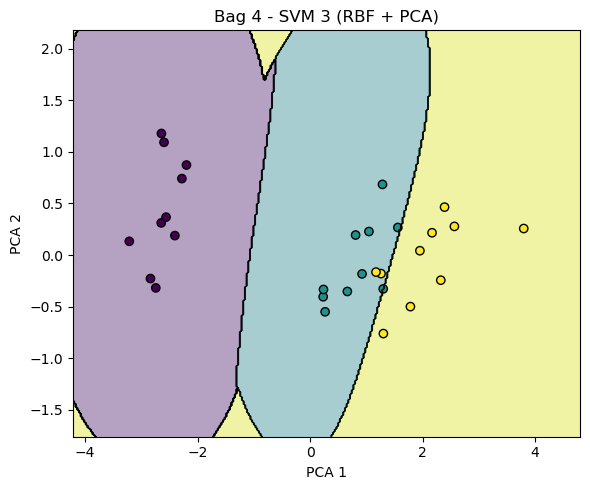

✅ Bag 4 Accuracy: 96.67%

========== BAG 5 ==========
SVM 1 trained (PCA space)


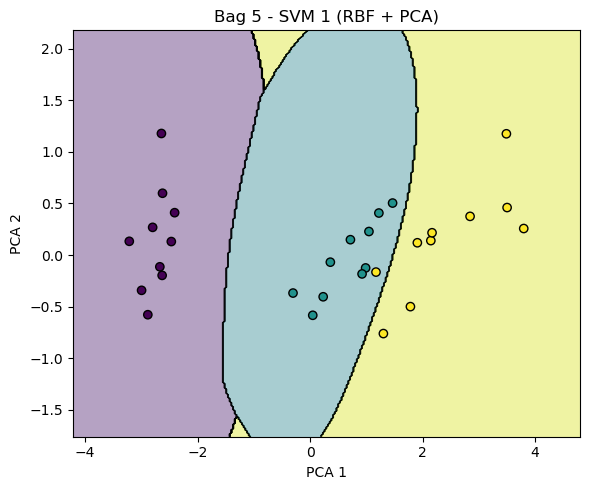

SVM 2 trained (PCA space)


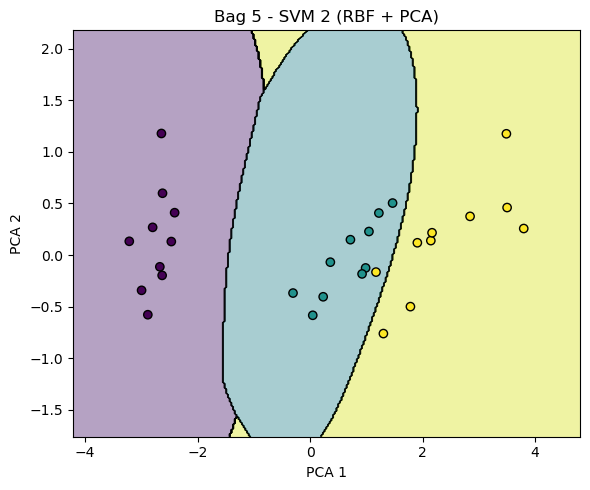

SVM 3 trained (PCA space)


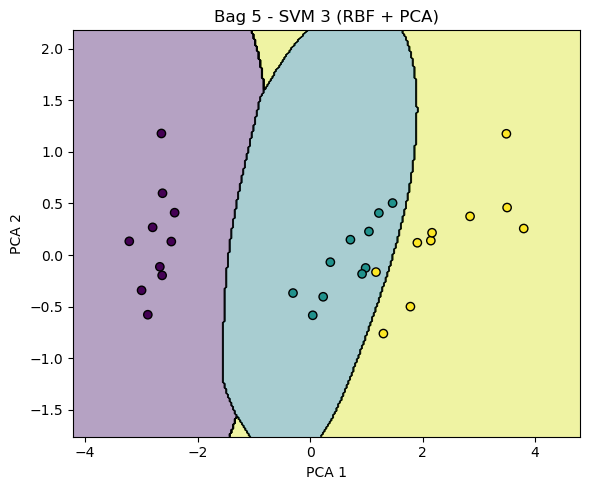

✅ Bag 5 Accuracy: 96.00%

 Final Model Accuracy: 96.67%
Example Prediction: setosa


In [16]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from collections import Counter
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# 🔹 PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

bags = 5
bag_predictions = []

for b in range(bags):
    indices = []

    # Class-wise sampling
    class_0 = np.where(y == 0)[0]
    class_1 = np.where(y == 1)[0]
    class_2 = np.where(y == 2)[0]

    indices.extend(np.random.choice(class_0, 10, replace=False))
    indices.extend(np.random.choice(class_1, 10, replace=False))
    indices.extend(np.random.choice(class_2, 10, replace=False))

    indices = np.array(indices)
    models = []

    print(f"\n========== BAG {b+1} ==========")

    for t in range(3):
        X_subset = X_pca[indices]
        y_subset = y[indices]

        # 🔥 SVM with RBF (smooth boundary)
        model = SVC(kernel='rbf', gamma='auto', C=1)
        model.fit(X_subset, y_subset)

        models.append(model)

        print(f"SVM {t+1} trained (PCA space)")

        # 🔹 Smooth decision boundary
        plt.figure(figsize=(6,5))

        x_min, x_max = X_subset[:, 0].min() - 1, X_subset[:, 0].max() + 1
        y_min, y_max = X_subset[:, 1].min() - 1, X_subset[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),   # high resolution
            np.linspace(y_min, y_max, 300)
        )

        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # 🔥 Smooth filled contours
        plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
        plt.contour(xx, yy, Z, colors='k', linewidths=0.5)

        # 🔹 Scatter points
        plt.scatter(
            X_subset[:, 0],
            X_subset[:, 1],
            c=y_subset,
            cmap='viridis',
            edgecolors='k'
        )

        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.title(f"Bag {b+1} - SVM {t+1} (RBF + PCA)")

        plt.tight_layout()
        plt.show()

    # 🔹 Prediction for this bag
    bag_pred = []

    for i in range(len(X_pca)):
        votes = []

        for model in models:
            pred = model.predict(X_pca[i].reshape(1, -1))[0]
            votes.append(pred)

        final_vote = Counter(votes).most_common(1)[0][0]
        bag_pred.append(final_vote)

    bag_predictions.append(bag_pred)

    # 🔹 Accuracy per bag
    correct = sum(1 for i in range(len(y)) if y[i] == bag_pred[i])
    acc = correct / len(y)

    print(f"✅ Bag {b+1} Accuracy: {acc*100:.2f}%")

# 🔹 Final ensemble prediction
final_predictions = []

for i in range(len(X_pca)):
    votes = [bag_predictions[b][i] for b in range(bags)]
    final_vote = Counter(votes).most_common(1)[0][0]
    final_predictions.append(final_vote)

# 🔹 Final accuracy
correct = sum(1 for i in range(len(y)) if y[i] == final_predictions[i])
final_acc = correct / len(y)

print(f"\n Final Model Accuracy: {final_acc*100:.2f}%")

# 🔹 Example output with class name
print("Example Prediction:", class_names[final_predictions[0]])